In [1]:
import numpy as np
import matplotlib.pyplot as plt
from define_data_and_variables import get_data, get_hmc_config
import arviz as az
import struct
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import os

In [2]:
data = get_data()
config, config_str = get_hmc_config(find_min = False, bias = "unified", cap = False, temp = True, umbrella = True)
find_min_config, config_find_min_str = get_hmc_config(find_min = True)
colors = plt.cm.viridis(np.linspace(0, 1, config["nch"]))
print(config["nl"])

101


In [3]:
samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_{config_str}.npy")
energy_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/energy_{config_str}.npy")
bias_values = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/bias_{config_str}.npy")
resampled_samples = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/resamp_{config_str}.npy")


In [4]:
print(energy_values)

[[ 96.48608057  91.09427746  97.02023737 ...  97.2850077   99.16716379
   99.89363368]
 [114.45469426 106.27250744 106.27250744 ... 144.20090934 152.30814213
  153.04359073]
 [105.63343898 104.14749267 104.14749267 ... 102.41167729 100.74549586
  101.13324275]
 [113.85929614 121.95742011 130.04802133 ... 123.41173123 127.37574397
  122.49399426]
 [104.88938306 120.88687853 137.09572558 ... 181.94251495 182.72737169
  183.52183356]]


In [12]:
nl = config["nl"] if config["nl"] != None else 1
nl2 = config["nl"] if config["npc"] == 2 else 1
nt = config["nt"] if config["nt"] != None else 1
temp_colors = plt.cm.viridis(np.linspace(0,1, nt))


In [13]:
files = [f"../../../../output/age_depth_OPES/deltaF_chain{i}_{config_str}.bin" for i in range(config["nch"])]
# Read every 10th element along the first axis (ns)
stride = 10
deltaF = []

for f in files:
    data = np.fromfile(f, dtype=np.float64)
    # reshape to full dimensions first
    data = data.reshape(config["ns"], nl, nl2, nt)
    # take every 10th element along the first axis
    deltaF.append(data[::stride])

deltaF = np.array(deltaF)
print(deltaF.shape)

(5, 1000, 101, 1, 2)


In [14]:
print("Reweighting energies for each temp\n")

if nt > 1:
    factors = np.arange(nt) / (nt - 1)
else:
    factors = np.array([0.0])

temp_centers = config["sbt"] * (config["ebt"] / config["sbt"]) ** factors

# Compute betas
betas = 1.0 / temp_centers

# Initial beta
beta0 = 1.0 / config["sbt"]
energy_samples = []
weights = []

for j in range(config["nt"]):
    temp_energy_samples = []
    weights = np.exp(-(betas[j] - beta0) * energy_values + bias_values)
    for i in range(config["nch"]):
        weights_i = weights[i, config["co"]:] / sum(weights[i, config["co"]:])
        indices = np.random.choice(
            np.arange(config["co"], len(weights_i) + config["co"]),
            size=int(len(weights_i)),
            replace=True,
            p=weights_i,
        )
        print(f"Chain {i} done resampling")
        temp_energy_samples.append(energy_values[i, indices])
    energy_samples.append(temp_energy_samples)
        
energy_samples = np.array(energy_samples)
print(np.shape(energy_samples))

Reweighting energies for each temp

Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
Chain 0 done resampling
Chain 1 done resampling
Chain 2 done resampling
Chain 3 done resampling
Chain 4 done resampling
(2, 5, 10000)


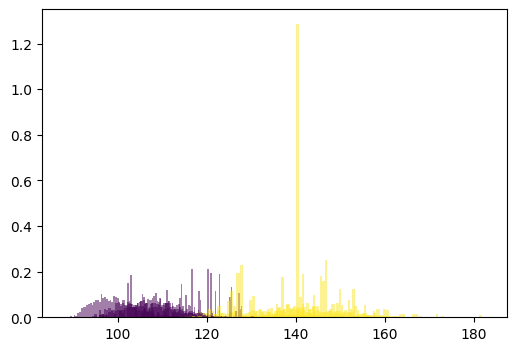

In [ ]:
for k in range(config["nch"]):
    fig, ax = plt.subplots(figsize=(6, 4))
    for i in range(nt):
        ax.hist(energy_samples[i, k, :], bins = 100, color = temp_colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

10


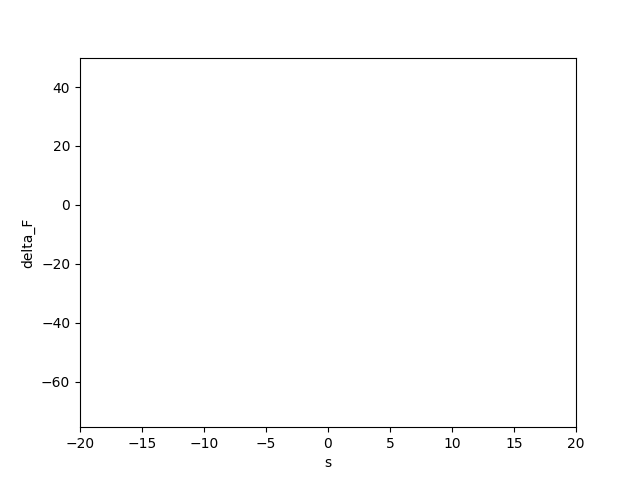

In [ ]:
%matplotlib widget

print(config["nt"])
if (not (config["npc"] == None)):

    if config["npc"] == 2:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])
        ycoords = np.linspace(config["sb"], config["eb"], config["nl"])

        X, Y = np.meshgrid(xcoords, ycoords)

        for i in range(config["nch"]):
            last_delta_F = np.squeeze(deltaF[i, -1, :, :, 9])
            indices = np.unravel_index(np.argmin(last_delta_F), last_delta_F.shape)
            print(deltaF[i, :, :, 0])
            print(f"Chain {i} min deltaF at: {indices}")
            print(xcoords[indices[0]])
            print(ycoords[indices[1]])
            print(f"{i}\n")
            print(last_delta_F[last_delta_F<50])
            plt.figure(figsize=(6,5))
            pcm = plt.pcolormesh(X, Y, last_delta_F.T, shading='auto', cmap='viridis') # This looks flipped, could be the plotting, but could also be the indexing.
            plt.colorbar(pcm, label='Value')
            plt.xlabel('X coordinate')
            plt.ylabel('Y coordinate')
            plt.title('2D Plot with coordinates')
            plt.show()
    if config["npc"] == 1:
        xcoords = np.linspace(config["sb"], config["eb"], config["nl"])

        fig, ax = plt.subplots()

        lines = []

        for j in range(nt):
            line, = ax.plot([], [], lw=2, label=f"T{j}", color = temp_colors[j])
            lines.append(line)
        ax.set_xlim(config["sb"], config["eb"])
        ax.set_ylim(np.min(deltaF), np.max(deltaF))

        ax.set_xlabel("s")
        ax.set_ylabel("delta_F")
        shorter_deltaF = deltaF[:, ::100, : , :, :]

        def update(frame):
            i = frame
            for j in range(nt):
                sample_delta_F = np.squeeze(shorter_deltaF[0, i, :, 0, j])
                lines[j].set_data(xcoords, sample_delta_F)
            ax.set_title(f"sample i={i}")
            return lines,
    
        frames = config["ns"]  # number of frames
        ani = FuncAnimation(fig, update, frames=frames, blit=False, interval=100, repeat = False)

        plt.show()

In [7]:
# starting_points = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/samples_min_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
# starting_energies = np.load(f"C:/Users/hanna/Desktop/PhD/Bacon/output/age_depth_OPES/Emin_dc2.00_a1.50_b0.21_nch4_N50_H100_nlsp24_mi100000_dt0.00_gl0.00.npy")
starting_energies = np.load(f"../../../../output/age_depth_OPES/Emin_{config_find_min_str}.npy")
starting_points = np.load(f"../../../../output/age_depth_OPES/samples_min_{config_find_min_str}.npy")
print(starting_energies)

[ 95.82593999 160.81503149  98.51794836 103.03485398 101.85631173
  96.41480715 175.364578    93.98629295 100.27035141 103.30341829
  96.9760657   92.85025439  98.77664828  95.47403137 166.73402062
 106.08955114 102.55836007  96.41503312  97.06198286 102.61538138
  97.22144971 166.97508882  98.25586272 159.29191304]


In [8]:
print(starting_points)
# print(np.sort(starting_energies))
sp_mean= np.mean(starting_points, axis = 0)
sp = starting_points-sp_mean
cov = np.cov(sp, rowvar=False)
eigenvalues, eigenvectors = np.linalg.eigh(cov)

idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

pc1 = eigenvectors[:, 0]
pc2 = eigenvectors[:, 1]

print(eigenvalues)
print(np.sum(eigenvalues[0:4])/np.sum(eigenvalues))
var_ratio = eigenvalues[0] / np.sum(eigenvalues)
var2_ratio = eigenvalues[1] / np.sum(eigenvalues)
print("Main direction at problem:", pc1[20:25])
print(np.abs(pc1) > 0.1)
print("Main direction:", pc1[np.abs(pc1) > 0.1])

print(np.linalg.norm(pc1))
print(30 * np.sum(pc1[pc1>0]))
print(30 * np.sum(pc1[pc1<0]))

[[ 2.79418374  4.52858206  5.91163311 ... 15.73609938  5.46834945
   7.18668404]
 [ 3.13752277  2.735891    0.1999274  ... 14.29024138  6.35385465
   7.11896571]
 [ 2.81473448  4.55725012  5.67717706 ... 16.52889703  4.75174367
   7.11554067]
 ...
 [ 3.23114209  2.48987415  0.10409423 ... 15.78057255  4.77436232
   7.28439606]
 [ 2.80160457  4.4717735   5.70351598 ... 16.23676995  5.81824473
   7.15904583]
 [ 3.34732639  2.62277076  0.10482999 ... 15.93404328  4.91552015
   7.10454998]]
[ 2.12432906e+01  1.25917413e+01  7.35460259e+00  2.78447744e+00
  2.20309116e+00  9.95535665e-01  4.80865255e-01  4.02794040e-01
  3.00687548e-01  2.74161443e-01  1.85325715e-01  1.71530300e-01
  1.32132616e-01  9.79456360e-02  8.47269678e-02  6.50038512e-02
  5.12646374e-02  4.40106198e-02  3.56650602e-02  2.48021028e-02
  1.74941425e-02  1.48842804e-02  1.06871371e-02  1.95648036e-15
  9.15205860e-16  7.74726900e-16  4.18625995e-16  3.65118007e-16
  2.51763075e-16  2.38408187e-16  9.11332116e-17  7.2

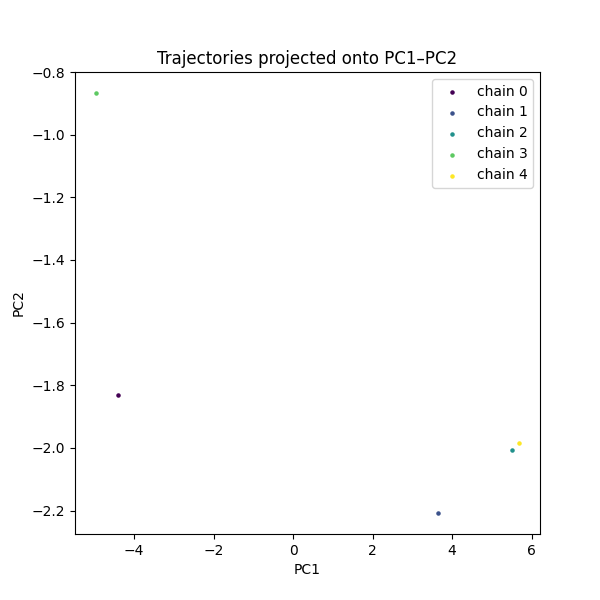

In [9]:
proj = []
for chain in range(samples.shape[0]):
    traj = samples[chain]
    traj_centered = traj - sp_mean
    coords = np.stack([traj_centered @ pc1,
                       traj_centered @ pc2], axis=1) # This should be the same as what i get when i print in C, maybe the indexing becomes wrong when i send in the pcs?
    proj.append(coords)

# Plot
fig, ax = plt.subplots(figsize=(6,6))

for chain, coords in enumerate(proj):
    ax.plot(coords[::200,0], coords[::200,1], alpha=0.3, color=colors[chain])
    ax.scatter(coords[::200,0], coords[::200,1], s=5, color=colors[chain], label=f"chain {chain}")

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_title("Trajectories projected onto PC1–PC2") # Something is weird, adding the exploration in pc2 makes it explore worse in pc1, something is still wrong.
ax.legend()
plt.show()

In [10]:
print(np.shape(resampled_samples))
print(np.shape(samples))

(5, 100, 50)
(5, 100, 50)


In [11]:
def expected_ages(N, delta_c, cs, theta, num_depths, depths, sed_rates, indices):
    cumulative_sum_vec = [0.0] * (N + 1)
    
    # Build cumulative sum vector
    for i in range(1, N + 1):
        cumulative_sum_vec[i] = cumulative_sum_vec[i - 1] + sed_rates[i - 1] * delta_c
    
    ages_out = [0.0] * num_depths
    
    # Compute ages
    for i in range(num_depths):
        index = indices[i]
        cumulative_sum = cumulative_sum_vec[index]
        cumulative_sum += sed_rates[index] * (depths[i] - cs[index])
        ages_out[i] = theta - cumulative_sum
    
    return ages_out


def get_index(N, cs, c14_depths, depth_index):
    low, high = 0, N - 1
    target = c14_depths[depth_index]
    
    while low <= high:
        mid = (low + high) // 2
        if cs[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    
    return low - 1 if low > 0 else 0

In [12]:
print(energy_values)

[[ 96.48608057  91.09427746  97.02023737 102.19771178 102.19771178
  102.19771178 102.19771178 102.19771178 102.19771178 102.19771178
  102.19771178 102.19771178 102.19771178 102.19771178 102.19771178
  102.19771178 102.19771178 102.19771178 102.19771178 102.19771178
  102.19771178 102.19771178 102.19771178 102.19771178 102.19771178
  102.19771178 102.19771178 102.19771178 102.19771178 102.19771178
  102.19771178 102.19771178 102.19771178 102.80055674  98.76123311
   98.76123311 102.52745057  97.82427526 105.10211271 103.87866972
  106.56884233  96.97847193  94.4889986   91.54288882  91.31315609
   91.31315609  91.31315609  91.31315609  91.31315609  91.31315609
   91.31315609  91.31315609  91.31315609  91.31315609  93.4252921
   91.15286409  91.15286409  94.29462082  98.44627157 102.58502882
  105.93914765 113.60018166 115.62439443 110.66012959 123.60230161
  125.52546721 114.5791636  114.0882077  119.38441431 126.35620383
  127.51302212 128.41196678 134.82073097 125.57704908 138.02527

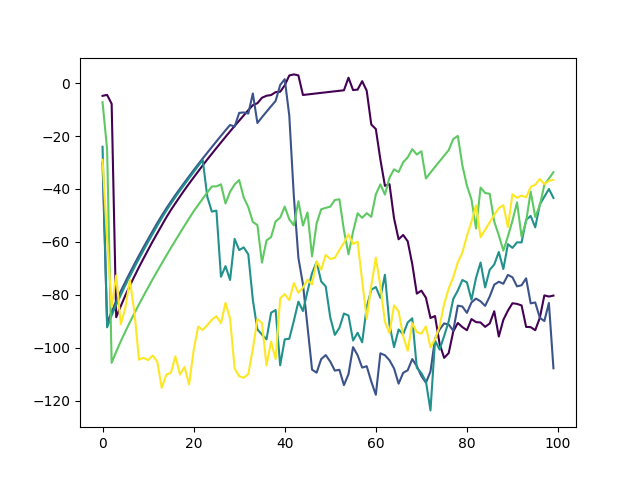

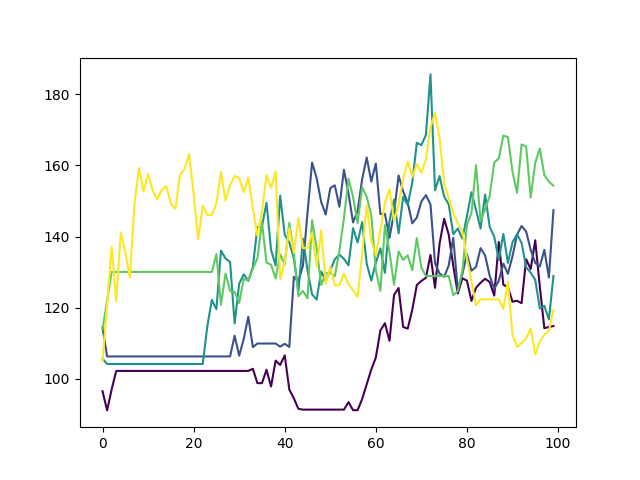

In [13]:
plt.figure()
for i in range(config["nch"]):
    plt.plot(bias_values[i,:], color = colors[i])
plt.show()

plt.figure()
for i in range(config["nch"]):
    plt.plot(energy_values[i,:], color = colors[i])
plt.show()


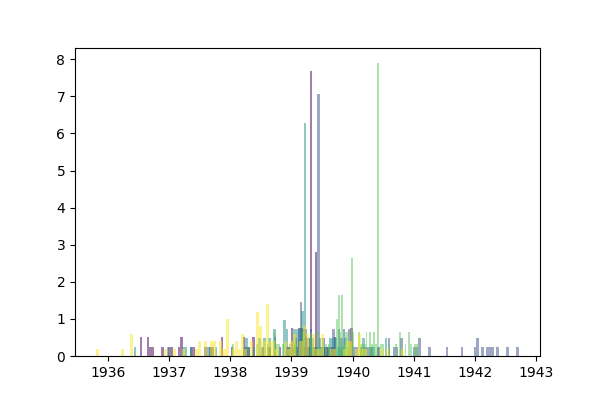

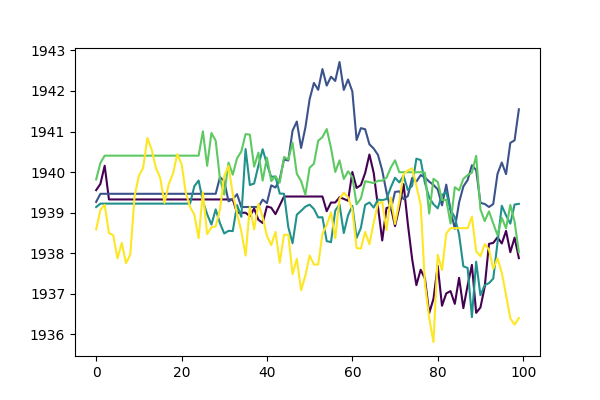

In [14]:
CV_values = data["theta"] - config["dc"] * np.sum(samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.plot(CV_values[i, :], color = colors[i], label = f"chain {i}")
plt.show()

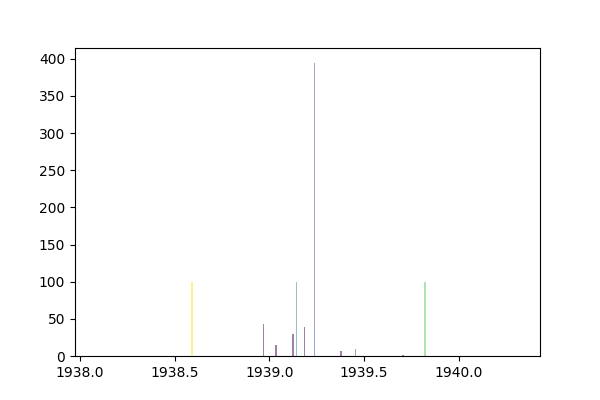

In [15]:
CV_values = data["theta"] - config["dc"] * np.sum(resampled_samples[:, :, :4], axis = 2)
fig, ax = plt.subplots(figsize=(6, 4))
for i in range(config["nch"]):
    ax.hist(CV_values[i, :], bins = 100, color = colors[i], label = f"chain {i}", alpha = 0.5, density = True)
plt.show()

In [16]:
resampled_samples = resampled_samples[:,::100,:]

In [17]:
print(np.max(bias_values))

3.286631722176468


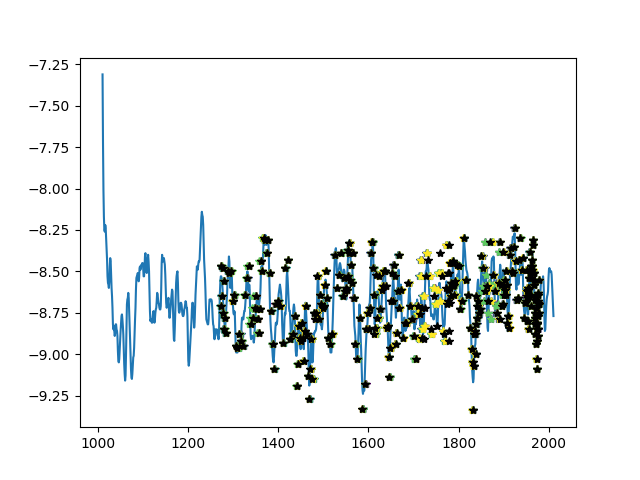

In [18]:
indices = []
for i in range(len(data["d18O_depths"])):
    index = get_index(config["N"], config["cs"], data["d18O_depths"], i)
    indices.append(index)

plt.figure()
plt.plot(data["d18O_reference_times"], data["d18O_reference"])
for i in range(config["nch"]):
    variables = resampled_samples[i,:,:]
    for j in range(len(variables)):
        d18O_ages = expected_ages(config["N"], config["dc"], config["cs"], data["theta"], len(data["d18O_depths"]), data["d18O_depths"], variables[j,:], indices)
        plt.plot(d18O_ages, data["d18O"], '*', color = colors[i])

plt.plot(data["true_ages_D18O"], data["d18O"], '*', color = "k")
plt.show()

In [19]:
# Print R_hat and N_eff using arviz
idata = az.convert_to_inference_data(resampled_samples)
summary = az.summary(idata, round_to=2)
print(summary)

c:\Users\hanna\Desktop\PhD\Bacon\bacon_venv\Lib\site-packages\arviz\data\base.py:272: UserWarning: More chains (5) than draws (1). Passed array should have shape (chains, draws, *shape)
  warnings.warn(
arviz - WARNING - Shape validation failed: input_shape: (5, 1), minimum_shape: (chains=1, draws=4)


        mean    sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  ess_tail  \
x[0]    2.64  0.27    2.19     2.84        NaN      NaN       NaN       NaN   
x[1]    4.81  0.40    4.48     5.45        NaN      NaN       NaN       NaN   
x[2]    5.77  0.29    5.34     6.05        NaN      NaN       NaN       NaN   
x[3]    6.19  0.31    5.79     6.60        NaN      NaN       NaN       NaN   
x[4]    6.79  0.36    6.39     7.18        NaN      NaN       NaN       NaN   
x[5]    4.92  0.25    4.55     5.25        NaN      NaN       NaN       NaN   
x[6]    4.03  0.30    3.68     4.48        NaN      NaN       NaN       NaN   
x[7]    3.26  0.90    2.55     4.34        NaN      NaN       NaN       NaN   
x[8]    4.61  2.43    2.79     7.65        NaN      NaN       NaN       NaN   
x[9]    6.88  1.84    5.24     9.32        NaN      NaN       NaN       NaN   
x[10]   5.99  0.98    5.02     7.03        NaN      NaN       NaN       NaN   
x[11]   8.50  4.15    3.68    12.05        NaN      

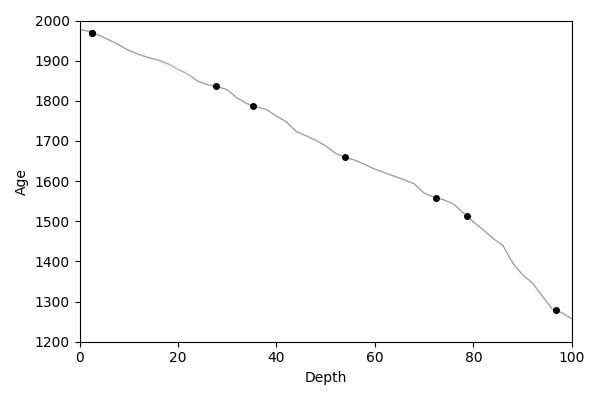

In [20]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     ax.axvline(x=c, color='k', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()

In [21]:
depths = np.sort(np.hstack((0, data["d18O_depths"])))
ages = np.flip(np.hstack((data["theta"], data["true_ages_D18O"]))) # why are they not sorted correctly?
# print(depths)
# print(ages)
sed_rates = [0]
theta = data["theta"]

pre_age = theta
pre_depth = 0
for i in range(1, config["N"] + 1):
    idx = np.searchsorted(depths, config["cs"][i])
    # print(np.sort(depths))
    # print(config["cs"][i])
    # print(idx)
    if idx < len(depths):
        upper_depth = depths[idx - 1]
        age = ages[idx - 1] + ((ages[idx] - ages[idx - 1])/(depths[idx] - depths[idx - 1]))*(config["cs"][i] - depths[idx-1])
        sed_rates.append((pre_age - age) / (config["cs"][i] - config["cs"][i-1]))
        pre_age = age
    else:
        sed_rates.append(config["a"] / config["b"])


print(sed_rates)
exp_ages = theta - np.cumsum(sed_rates) * config["dc"]
print(exp_ages)
print(np.max(sed_rates))

[0, np.float64(2.961999999999989), np.float64(4.918999999999983), np.float64(5.424000000000092), np.float64(7.48792682926819), np.float64(6.232073170731724), np.float64(4.960348837209267), np.float64(3.886079734219379), np.float64(2.3600487012986378), np.float64(3.077159090909049), np.float64(5.722077922077915), np.float64(10.704053156146301), np.float64(8.34939922480612), np.float64(3.580958333333342), np.float64(2.1794903846154057), np.float64(5.24633699633705), np.float64(10.239729437229357), np.float64(6.853863636363712), np.float64(2.800787878787901), np.float64(2.2284166666665897), np.float64(1.326249999999959), np.float64(3.7012500000000728), np.float64(11.959886363636315), np.float64(13.616363636363644), np.float64(9.235416666666652), np.float64(8.99635416666672), np.float64(7.4015624999999545), np.float64(4.2762943262411), np.float64(4.733872340425592), np.float64(4.755707317073188), np.float64(5.887838137472272), np.float64(6.097495361781057), np.float64(3.2143877551020523), 

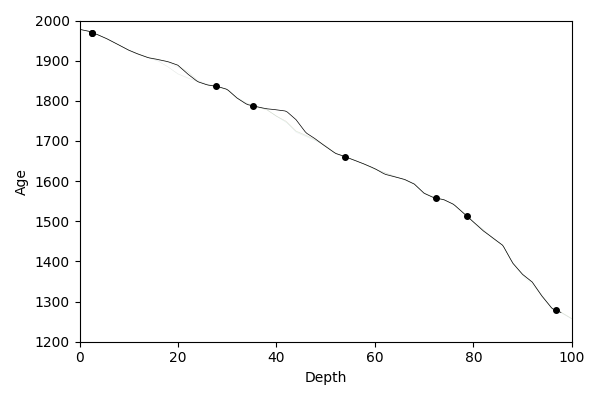

In [22]:
cumulative_sums = np.cumsum(resampled_samples[:, :,:], axis=2) * config["dc"]
zeros = np.zeros((*resampled_samples[:,:,:].shape[:2], 1))
age_offsets = np.concatenate((zeros, cumulative_sums), axis=2)

model_ages = data["theta"] - age_offsets

mean_model_age = model_ages.mean(axis=(0, 1))

# Age depth trace plot
fig, ax = plt.subplots(figsize=(6, 4))
num_samples = len(resampled_samples[0,:,0])
for i in range(config["nch"]):
    for j in range(num_samples):
        ax.plot(
            config["cs"],
            model_ages[i, j, :],
            color=colors[i],
            alpha=0.3,
            linewidth=0.1,
        )
# for i, c in enumerate(config["cs"]):
#     if i != config["pidx"]:
#         ax.axvline(x=c, color='k', linestyle='--')
#     else:
#         ax.axvline(x=c, color='r', linestyle='--')

ax.set_xlim(0, np.max(config["cs"]))
ax.set_ylim(1200, 2000)
# plt.plot(config["cs"], mean_model_age, color="black", alpha=0.3, linewidth=1)
# plt.plot(config["cs"], exp_ages, color = 'r', linewidth = 0.5)
plt.plot(data["c14_depths"], np.squeeze(data["c14_ages"]), "ko", markersize=4)
plt.plot(data["d18O_depths"], data["true_ages_D18O"], color = 'k', linewidth=0.5)
# plt.plot(config["cs"], data["theta"] - config["dc"] * np.cumsum((config["a"]/config["b"]) * np.ones_like(config["cs"])), color = 'k', linewidth=0.5)
plt.xlabel("Depth")
plt.ylabel("Age")
plt.tight_layout()
plt.show()